# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [70]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')

feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share',
]

In [71]:
price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]
print("Estimated price coefficient:", price_coef)

results = df.copy()
results["predicted_log_share"] = predicted_log_share
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]
results["profit_derivative"] = (
    results["demand_slope"] * results["markup"] + results["brand_share"]
)

print(results[["unit_cost", "markup", "average_profit", "profit_derivative"]].describe())

Estimated price coefficient: -0.03766765298429383
        unit_cost     markup  average_profit  profit_derivative
count   50.000000  50.000000       50.000000       5.000000e+01
mean    93.102239  29.703894        3.155916       2.985893e-18
std     51.696080   2.615822        2.615822       1.753363e-17
min     22.002913  26.567362        0.019385      -2.775558e-17
25%     53.159061  27.952365        1.404387      -3.903128e-18
50%     70.038270  28.813285        2.265308       0.000000e+00
75%    123.561937  30.956852        4.408875       1.214306e-17
max    199.729962  37.507010       10.959033       5.551115e-17


In [72]:
# average unit costs and markups for each brand over the years
results[[
    'brand',
    'markup',
    'unit_cost',
    'average_profit',
]].groupby('brand').mean()

,markup,unit_cost,average_profit
brand,,,
chefman,29.368946,61.569466,2.820968
cosori,27.984628,86.283321,1.436651
cuisinart,29.050974,194.896119,2.502997
dash,29.542349,27.936578,2.994372
gowise usa,31.153741,56.301040,4.605764
instant_pot,32.558234,71.903119,6.010256
ninja,32.854071,112.488470,6.306093
nuwave,27.970835,109.053549,1.422858
oster,27.226315,161.804969,0.678338


In [73]:
# Checking if unit costs are negative
negative_costs = results[results['unit_cost'] < 0]
print(f"Negative Unit Costs")
print(f"Number of observations with negative unit costs: {len(negative_costs)}")
if len(negative_costs) > 0:
    print(negative_costs[['brand', 'year', 'unit_cost', 'avg_price', 'brand_share', 'demand_slope']])
print()

Negative Unit Costs
Number of observations with negative unit costs: 0



In [74]:
#Which brands have the highest average unit costs?
brand_summary = results.groupby('brand').agg({
    'unit_cost': 'mean',
}).round(2)
brand_summary = brand_summary.sort_values('unit_cost', ascending=False)
print(brand_summary)
print()

             unit_cost
brand                 
cuisinart       194.90
oster           161.80
ninja           112.49
nuwave          109.05
cosori           86.28
instant_pot      71.90
chefman          61.57
gowise usa       56.30
ultrean          48.79
dash             27.94



In [75]:
#How do average unit cost and average ratings compare?
brand_summary = results.groupby('brand').agg({
    'unit_cost': 'mean',
    'avg_rating': 'mean'
}).round(2)
brand_summary

,unit_cost,avg_rating
brand,,
chefman,61.57,4.43
cosori,86.28,4.66
cuisinart,194.90,4.44
dash,27.94,4.48
gowise usa,56.30,4.58
instant_pot,71.90,4.56
ninja,112.49,4.74
nuwave,109.05,4.39
oster,161.80,4.39


When viewing the average rating to unit cost on scattter plot, it shows that the middle to lower ranged brands tend to have better average rating compared to the higher unit cost brands

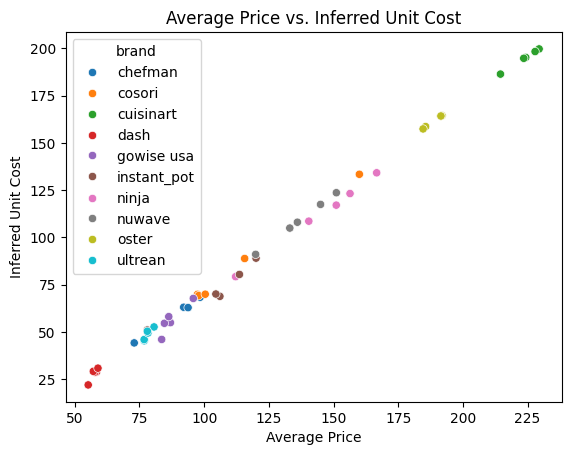

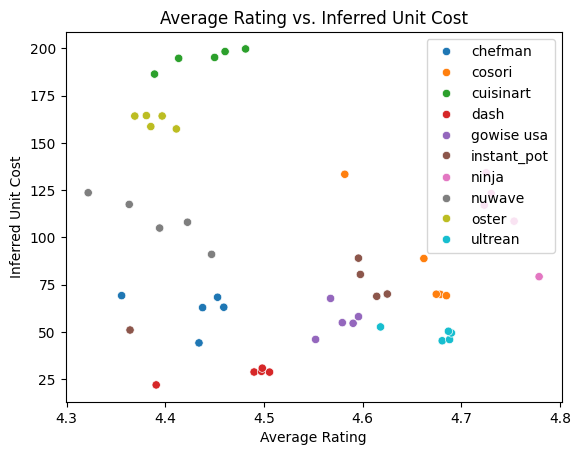

In [76]:
#Make scatter plots of price vs. unit cost and average rating vs. unit cost.
# Scatterplot of price v. unit cost:
sns.scatterplot(data=results, x='avg_price', y='unit_cost', hue='brand')
plt.title('Average Price vs. Inferred Unit Cost')
plt.xlabel('Average Price')
plt.ylabel('Inferred Unit Cost')
plt.show()

# Scatterplot of average rating v. unit cost:
sns.scatterplot(data=results, x='avg_rating', y='unit_cost', hue='brand')
plt.title('Average Rating vs. Inferred Unit Cost')
plt.xlabel('Average Rating')
plt.ylabel('Inferred Unit Cost')
plt.legend(loc='upper right')
plt.show()

Do more expensive products have higher consumer satisfaction?
More expensive products do not necessarily have higher consumer satisfaction. The one that has highest consumer satisfaction is the ninja and that is middle price compared to the rest of the brands. The scatter plot shows lower priced products seem to have a better consumer satisfaction rate.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

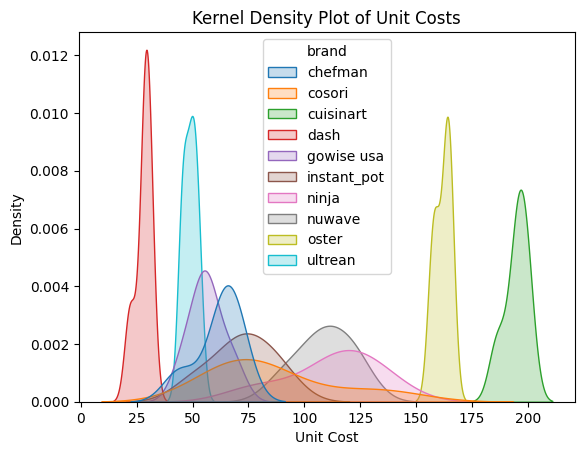

In [77]:
#Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand
# Kernel density plot of unit costs:
sns.kdeplot(data=results, x='unit_cost', hue='brand', fill=True)
plt.title('Kernel Density Plot of Unit Costs')
plt.xlabel('Unit Cost')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

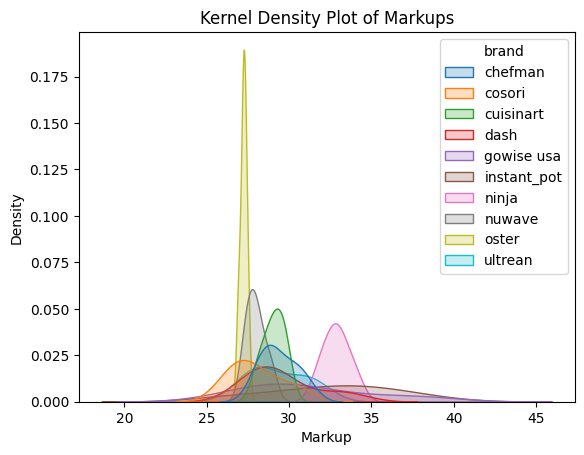

In [78]:
# Kernel density plot of markups:
sns.kdeplot(data=results, x='markup', hue='brand', fill=True)
plt.title('Kernel Density Plot of Markups')
plt.xlabel('Markup')
plt

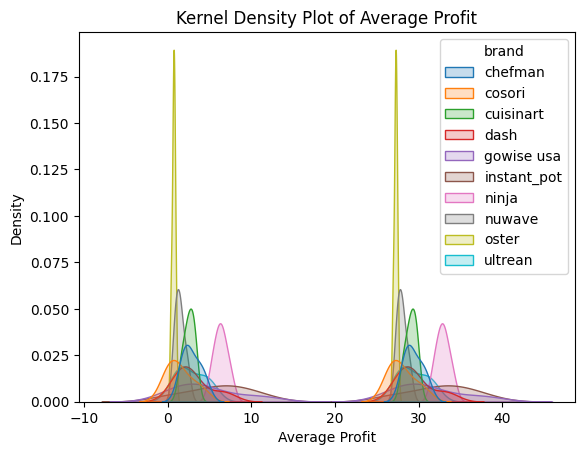

In [79]:
# Kernel density plot of Average Profit
sns.kdeplot(data=results, x='markup', hue='brand', fill=True)
plt.title('Kernel Density Plot of Markups')
plt.xlabel('Markup')
plt
sns.kdeplot(data=results, x='average_profit', hue='brand', fill=True)
plt.title('Kernel Density Plot of Average Profit')
plt.xlabel('Average Profit')
plt.show()

In [80]:
#Which brands have the highest share-weighted average profit?
brand_summary = results.groupby('brand').agg({
    'average_profit': 'mean',
}).round(2)
brand_summary = brand_summary.sort_values('average_profit', ascending=False)
print(brand_summary)
print()

             average_profit
brand                      
ninja                  6.31
instant_pot            6.01
gowise usa             4.61
dash                   2.99
chefman                2.82
ultrean                2.78
cuisinart              2.50
cosori                 1.44
nuwave                 1.42
oster                  0.68



Ninja brand has the highest shared-weighted average profit of all the brands being analyzed in this report.